In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import BernoulliNB, CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTEN

from utils import clean_data

In [2]:
_RANDOM_STATE = 42
_CATEGORICAL_COLS = [
    'Pfam domains', 'HGNC gene family tag', 'HGNC gene family description', 
    'Function', 'Modification', 'Protein complex', 'Target molecule',
    'Target entity', 'Product'
]

input_data_filename = "./data/dataset_cleaned_397.csv"
raw_data = pd.read_csv(input_data_filename)
X, y, class_labels = clean_data(raw_data)
ord_X = pd.DataFrame(OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(X), columns=X.columns)

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from imblearn.pipeline import Pipeline


def make_rew_classifier(
    clf,
    smote=True,
    onehot=True,
    var_filter__threshold=0.16,
    ft_filter__k=9,
    random_state=42
):
    steps = []

    if smote:
        steps.append(("smote", SMOTEN(random_state=random_state)))

    if onehot:
        steps.append(("onehot", ColumnTransformer(
            [("onehot", OneHotEncoder(handle_unknown="ignore"), _CATEGORICAL_COLS)],
            remainder='passthrough'
        )))

    steps += [
        ("var_filter", VarianceThreshold(threshold=var_filter__threshold)),
        ("ft_filter", SelectKBest(score_func=f_classif, k=ft_filter__k)),
        ("clf", clf)
    ]
    return Pipeline(steps)


def best_model_config(
    pipe,
    X,
    y,
    param_grid,
    cv=5,
    scoring='f1_macro'
):
    grid_search = GridSearchCV(
        pipe, 
        param_grid, 
        scoring=scoring, 
        refit=True, 
        cv=cv)
    grid_search.fit(X, y)
    return grid_search

In [4]:
def evaluate(model, X, y_truth, decimals=3):
    y_proba = model.predict_proba(X)
    y_preds = np.argmax(y_proba, axis=1)
    return {
        'ACCURACY': np.round(accuracy_score(y_truth, y_preds), decimals),
        'F1 SCORE': np.round(f1_score(y_truth, y_preds, average='weighted'), decimals),
        'AUC': np.round(roc_auc_score(y_truth, y_proba, multi_class='ovr'), decimals)
    }

Naive Bayes

In [9]:
def collapse_rare_categories(df, categorical_cols, min_freq=10):
    df = df.copy()
    
    for col in categorical_cols:
        counts = df[col].value_counts()
        rare = counts[counts < min_freq].index
        
        df[col] = df[col].where(~df[col].isin(rare), other=-1)
    return df
modified_ord_X = collapse_rare_categories(ord_X, _CATEGORICAL_COLS) + 1

nb_cat = make_rew_classifier(CategoricalNB())
nb_cat_param_grid = {
    'smote': [SMOTEN(random_state=_RANDOM_STATE), 'passthrough'],
    'onehot': ['passthrough'],
    'var_filter__threshold': [0, 0.05, 0.1, 0.16, 0.25],
    'ft_filter__k': [7, 8, 9],
    'clf__alpha': [0, 0.25, 0.5, 0.75, 1]
}
best_nb_cat = best_model_config(
    nb_cat,
    modified_ord_X,
    y, 
    nb_cat_param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5),
)

c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1561: RuntimeWarning: divide by zero encountered in log
  np.log(smoothed_cat_count) - np.log(smoothed_class_count.reshape(-1, 1))
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1561: RuntimeWarning: divide by zero encountered in log
  np.log(smoothed_cat_count) - np.log(smoothed_class_count.reshape(-1, 1))
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1561: RuntimeWarning: divide by zero encountered in log
  np.log(smoothed_cat_count) - np.log(smoothed_class_count.reshape(-1, 1))
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1561: RuntimeWarning: divide by zero encountered in log
  np.log(smoothed_cat_count) - np.log(smoothed_class_count.reshape(-1, 1))
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1561: RuntimeWarning: divi

In [8]:
nb_bnl = make_rew_classifier(BernoulliNB())
nb_bnl_param_grid = {
    'smote': [SMOTEN(random_state=_RANDOM_STATE), 'passthrough'],
    'var_filter__threshold': [0, 0.05, 0.1, 0.16, 0.25],
    'ft_filter__k': [7, 8, 9],
    'clf__alpha': [0, 0.25, 0.5, 0.75, 1]
}
best_nb_bnl = best_model_config(
    nb_bnl,
    X,
    y, 
    nb_bnl_param_grid,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=5),
)

c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1241: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1241: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1241: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1241: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1241: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed

In [10]:
print(f'Categorical NB:\t{best_nb_cat.best_score_:.3}')
print(f'Bernoulli NB:\t{best_nb_bnl.best_score_:.3}')

Categorical NB:	0.86
Bernoulli NB:	0.892


In [13]:
nb_res = pd.DataFrame(best_nb_bnl.cv_results_)
nb_best_score = nb_res["mean_test_score"].max()
nb_res[nb_res["mean_test_score"] == nb_best_score]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__alpha,param_ft_filter__k,param_smote,param_var_filter__threshold,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,0.050071,0.033788,0.009435,0.005839,0.0,7,SMOTEN(random_state=42),0.16,"{'clf__alpha': 0, 'ft_filter__k': 7, 'smote': ...",0.8875,0.875,0.949367,0.860759,0.886076,0.891741,0.030368,1
7,0.012170,0.006242,0.007708,0.005463,0.0,7,passthrough,0.10,"{'clf__alpha': 0, 'ft_filter__k': 7, 'smote': ...",0.8875,0.875,0.949367,0.860759,0.886076,0.891741,0.030368,1
8,0.013913,0.005310,0.009232,0.007658,0.0,7,passthrough,0.16,"{'clf__alpha': 0, 'ft_filter__k': 7, 'smote': ...",0.8875,0.875,0.949367,0.860759,0.886076,0.891741,0.030368,1
13,0.036123,0.002598,0.006718,0.000778,0.0,8,SMOTEN(random_state=42),0.16,"{'clf__alpha': 0, 'ft_filter__k': 8, 'smote': ...",0.8875,0.875,0.949367,0.860759,0.886076,0.891741,0.030368,1
18,0.013373,0.006688,0.009767,0.007987,0.0,8,passthrough,0.16,"{'clf__alpha': 0, 'ft_filter__k': 8, 'smote': ...",0.8875,0.875,0.949367,0.860759,0.886076,0.891741,0.030368,1
23,0.030188,0.006127,0.006696,0.008202,0.0,9,SMOTEN(random_state=42),0.16,"{'clf__alpha': 0, 'ft_filter__k': 9, 'smote': ...",0.8875,0.875,0.949367,0.860759,0.886076,0.891741,0.030368,1
25,0.009860,0.008051,0.010076,0.008227,0.0,9,passthrough,0.00,"{'clf__alpha': 0, 'ft_filter__k': 9, 'smote': ...",0.8875,0.875,0.949367,0.860759,0.886076,0.891741,0.030368,1
26,0.016678,0.000334,0.003413,0.006827,0.0,9,passthrough,0.05,"{'clf__alpha': 0, 'ft_filter__k': 9, 'smote': ...",0.8875,0.875,0.949367,0.860759,0.886076,0.891741,0.030368,1
28,0.014432,0.005679,0.008624,0.004130,0.0,9,passthrough,0.16,"{'clf__alpha': 0, 'ft_filter__k': 9, 'smote': ...",0.8875,0.875,0.949367,0.860759,0.886076,0.891741,0.030368,1


Feed Forward Neural Network

In [6]:
fnn_classifier = make_rew_classifier(clf=MLPClassifier())

fnn_param_grid = {
    'smote': [SMOTEN(random_state=_RANDOM_STATE), 'passthrough'],
    'var_filter__threshold': [0, 0.05, 0.1, 0.16, 0.25],
    'ft_filter__k': [7, 8, 9],
    'clf__activation': ['tanh', 'relu'],
    'clf__max_iter': [200, 500, 750, 1000],
}

best_fnn = best_model_config(
    fnn_classifier,
    X,
    y, 
    fnn_param_grid,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=5),
)

c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converge

In [7]:
print(f'FNN:\t{best_fnn.best_score_:.3}')
fnn_res = pd.DataFrame(best_fnn.cv_results_)
fnn_best_score = fnn_res["mean_test_score"].max()
fnn_res[fnn_res["mean_test_score"] == fnn_best_score]

FNN:	0.889


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__activation,param_clf__max_iter,param_ft_filter__k,param_smote,param_var_filter__threshold,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,0.800693,0.068781,0.012430,0.005538,tanh,200,7,SMOTEN(random_state=42),0.16,"{'clf__activation': 'tanh', 'clf__max_iter': 2...",0.8875,0.8625,0.911392,0.898734,0.886076,0.889241,0.01618,1
8,0.522667,0.010358,0.007219,0.003610,tanh,200,7,passthrough,0.16,"{'clf__activation': 'tanh', 'clf__max_iter': 2...",0.8875,0.8625,0.911392,0.898734,0.886076,0.889241,0.01618,1
17,0.506599,0.025504,0.010916,0.007978,tanh,200,8,passthrough,0.10,"{'clf__activation': 'tanh', 'clf__max_iter': 2...",0.8875,0.8625,0.911392,0.898734,0.886076,0.889241,0.01618,1
25,0.543088,0.059891,0.010729,0.008143,tanh,200,9,passthrough,0.00,"{'clf__activation': 'tanh', 'clf__max_iter': 2...",0.8875,0.8625,0.911392,0.898734,0.886076,0.889241,0.01618,1
47,0.612202,0.089421,0.007875,0.007058,tanh,500,8,passthrough,0.10,"{'clf__activation': 'tanh', 'clf__max_iter': 5...",0.8875,0.8625,0.911392,0.898734,0.886076,0.889241,0.01618,1
68,0.535918,0.031385,0.008148,0.000679,tanh,750,7,passthrough,0.16,"{'clf__activation': 'tanh', 'clf__max_iter': 7...",0.8875,0.8625,0.911392,0.898734,0.886076,0.889241,0.01618,1
98,0.500745,0.052085,0.011311,0.004368,tanh,1000,7,passthrough,0.16,"{'clf__activation': 'tanh', 'clf__max_iter': 1...",0.8875,0.8625,0.911392,0.898734,0.886076,0.889241,0.01618,1
107,0.563785,0.100971,0.010708,0.004148,tanh,1000,8,passthrough,0.10,"{'clf__activation': 'tanh', 'clf__max_iter': 1...",0.8875,0.8625,0.911392,0.898734,0.886076,0.889241,0.01618,1


K-Nearest Neighbors

In [ ]:
knn_classifier = make_rew_classifier(clf=KNeighborsClassifier())

knn_param_grid = {
    'smote': [SMOTEN(random_state=_RANDOM_STATE), 'passthrough'],
    'var_filter__threshold': [0, 0.05, 0.1, 0.16, 0.25],
    'ft_filter__k': [7, 8, 9],
    'clf__n_neighbors': [3, 5, 9],
    'clf__weights': ['uniform', 'distance'],
    'clf__p': [1, 2]
}

best_knn = best_model_config(
    knn_classifier,
    X,
    y, 
    knn_param_grid,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=5),
)

c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=9 is greater than n_features=8. All the features will be returned.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=9 is greater than n_features=8. All the features will be returned.
  warnings.warn(
c:\

KNN:	0.879


c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=9 is greater than n_features=8. All the features will be returned.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=9 is greater than n_features=8. All the features will be returned.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
360 fits failed out of a total of 1800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
360 fits failed with the following error:
Traceback (most recent call last):
  File "

In [25]:
print(f'KNN:\t{best_knn.best_score_:.3}')
knn_res = pd.DataFrame(best_knn.cv_results_)
knn_best_score = knn_res['mean_test_score'].max()
knn_res[knn_res['mean_test_score'] == knn_best_score]

KNN:	0.879


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__n_neighbors,param_clf__p,param_clf__weights,param_ft_filter__k,param_smote,param_var_filter__threshold,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
307,0.012843,0.009381,0.010263,0.006257,9,2,uniform,7,passthrough,0.1,"{'clf__n_neighbors': 9, 'clf__p': 2, 'clf__wei...",0.8875,0.85,0.949367,0.873418,0.835443,0.879146,0.039479,1


Decision Tree

In [8]:
dt_classifier = make_rew_classifier(DecisionTreeClassifier(
    random_state=_RANDOM_STATE
))

dt_param_grid = {
    'smote': [SMOTEN(random_state=_RANDOM_STATE), 'passthrough'],
    'var_filter__threshold': [0, 0.05, 0.1, 0.16, 0.25],
    'ft_filter__k': [7, 8, 9],
    'clf__max_depth': [3, 5, 7, 10],
    'clf__min_samples_split': [2, 5, 10, 20],
    'clf__min_samples_leaf': [1, 2, 5, 10],
    'clf__max_features': [None, 'sqrt', 'log2'],
    'clf__criterion': ['gini', 'entropy'],
    'clf__ccp_alpha': [0.0, 1e-4, 1e-3, 1e-2],
    'clf__class_weight': [None, 'balanced']
}

best_dt = best_model_config(
    dt_classifier,
    X,
    y,
    dt_param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring='accuracy'
)

c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=9 is greater than n_features=8. All the features will be returned.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=9 is greater than n_features=8. All the features will be returned.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=9 is greater than n_features=8. All the features will be returned.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=9 is greater than n_features=8. All the features will be returned.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\feature_selection\_univariate_selecti

In [9]:
print(f'DT:\t{best_dt.best_score_:.3}')
dt_res = pd.DataFrame(best_dt.cv_results_)
dt_best_score = dt_res['mean_test_score'].max()
dt_res[dt_res['mean_test_score'] == dt_best_score]

DT:	0.897


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__ccp_alpha,param_clf__class_weight,param_clf__criterion,param_clf__max_depth,param_clf__max_features,param_clf__min_samples_leaf,...,param_var_filter__threshold,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
74092,0.024175,0.007043,0.011747,0.007527,0.01,NaN,gini,10,sqrt,2,...,0.1,"{'clf__ccp_alpha': 0.01, 'clf__class_weight': ...",0.8875,0.875,0.936709,0.911392,0.873418,0.896804,0.024142,1
74572,0.030002,0.008448,0.007981,0.007543,0.01,NaN,gini,10,log2,2,...,0.1,"{'clf__ccp_alpha': 0.01, 'clf__class_weight': ...",0.8875,0.875,0.936709,0.911392,0.873418,0.896804,0.024142,1
85612,0.030941,0.008976,0.004953,0.006209,0.01,balanced,gini,10,sqrt,2,...,0.1,"{'clf__ccp_alpha': 0.01, 'clf__class_weight': ...",0.8875,0.875,0.936709,0.911392,0.873418,0.896804,0.024142,1
86092,0.026343,0.007379,0.005984,0.006145,0.01,balanced,gini,10,log2,2,...,0.1,"{'clf__ccp_alpha': 0.01, 'clf__class_weight': ...",0.8875,0.875,0.936709,0.911392,0.873418,0.896804,0.024142,1


In [23]:
dt_res.iloc[86092].params

{'clf__ccp_alpha': 0.01,
 'clf__class_weight': 'balanced',
 'clf__criterion': 'gini',
 'clf__max_depth': 10,
 'clf__max_features': 'log2',
 'clf__min_samples_leaf': 2,
 'clf__min_samples_split': 5,
 'ft_filter__k': 9,
 'smote': SMOTEN(random_state=42),
 'var_filter__threshold': 0.1}

Artificial Neural Network

In [28]:
ann_classifier = make_rew_classifier(MLPClassifier())

ann_param_grid = {
    'smote': [SMOTEN(random_state=_RANDOM_STATE), 'passthrough'],
    'var_filter__threshold': [0, 0.05, 0.1, 0.16, 0.25],
    'ft_filter__k': [7, 8, 9],
    'clf__activation': ['tanh', 'relu'],
    'clf__max_iter': [200, 500, 750, 1000],
    'clf__hidden_layer_sizes': [(16,), (32,), (32, 16), (16,8), (32, 32, 32),]
}

best_ann = best_model_config(
    ann_classifier,
    X,
    y, 
    ann_param_grid,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=5),
)

c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converge

In [29]:
print(f'ANN:\t{best_ann.best_score_:.3}')
ann_res = pd.DataFrame(best_ann.cv_results_)
ann_best_score = ann_res['mean_test_score'].max()
ann_res[ann_res['mean_test_score'] == ann_best_score]

ANN:	0.902


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__activation,param_clf__hidden_layer_sizes,param_clf__max_iter,param_ft_filter__k,param_smote,param_var_filter__threshold,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
626,0.539634,0.172239,0.016119,0.002359,relu,"(16,)",200,9,passthrough,0.05,"{'clf__activation': 'relu', 'clf__hidden_layer...",0.8875,0.875,0.949367,0.898734,0.898734,0.901867,0.025315,1


Random Forest

In [29]:
rf_classifier = make_rew_classifier(RandomForestClassifier())

# rf_param_grid = {
#     'smote': [SMOTEN(random_state=_RANDOM_STATE), 'passthrough'],
#     'var_filter__threshold': [0, 0.1, 0.16,0.25],
#     'ft_filter__k': [7,8,9],
#     'clf__n_estimators': [100, 200, 500],
#     'clf__max_depth': [None, 5, 10, 20],
#     'clf__min_samples_split': [2 ,5, 10],
#     'clf__min_samples_leaf': [1, 2, 5],
#     'clf__max_features': ['sqrt', 'log2'],
#     'clf__class_weight': [None, 'balanced'],
#     'clf__ccp_alpha': [0.0, 1e-4, 1e-3]
# }

rf_param_grid = {
    'smote': ['passthrough'],
    'var_filter__threshold': [0],
    'ft_filter__k': [9],
    'clf__n_estimators': [200],
    'clf__max_depth': [5],
    'clf__min_samples_split': [5],
    'clf__min_samples_leaf': [5],
    'clf__max_features': ['sqrt'],
    'clf__class_weight': ['balanced'],
    'clf__ccp_alpha': [1e-3]
}


from sklearn.model_selection import RandomizedSearchCV
def rf_model_config(
    pipe,
    X,
    y,
    param_grid,
    cv=5,
    scoring='f1_macro'
):
    grid_search = RandomizedSearchCV(
        pipe, 
        param_grid, 
        n_iter=1000,
        scoring=scoring, 
        refit=True, 
        cv=cv)
    grid_search.fit(X, y)
    return grid_search

best_rf = rf_model_config(
    rf_classifier,
    X, 
    y, 
    rf_param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring="accuracy"
)

c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 1 is smaller than n_iter=1000. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [30]:
print(f'Random Forest:\t{best_rf.best_score_:.3}')
rf_res = pd.DataFrame(best_rf.cv_results_)
rf_best_score = rf_res['mean_test_score'].max()
rf_res[rf_res['mean_test_score'] == rf_best_score].iloc[:, [4,5,6,7,8,9,10,11,12,13,20]]

Random Forest:	0.882


,param_var_filter__threshold,param_smote,param_ft_filter__k,param_clf__n_estimators,param_clf__min_samples_split,param_clf__min_samples_leaf,param_clf__max_features,param_clf__max_depth,param_clf__class_weight,param_clf__ccp_alpha,mean_test_score
0,0,passthrough,9,200,5,5,sqrt,5,balanced,0.001,0.881741


In [ ]:
# 0.882
rf_best_score5 = rf_res5['mean_test_score'].max()
rf_res5[rf_res5['mean_test_score'] == rf_best_score5].iloc[:, [4,5,6,7,8,9,10,11,12,13,20]]

,param_var_filter__threshold,param_smote,param_ft_filter__k,param_clf__n_estimators,param_clf__min_samples_split,param_clf__min_samples_leaf,param_clf__max_features,param_clf__max_depth,param_clf__class_weight,param_clf__ccp_alpha,mean_test_score
194,0.16,passthrough,8,500,5,5,log2,20,NaN,0.0,0.881741


In [ ]:
# 0.882
rf_best_score4 = rf_res4['mean_test_score'].max()
rf_res4[rf_res4['mean_test_score'] == rf_best_score4].iloc[:, [4,5,6,7,8,9,10,11,12,13,20]]

,param_var_filter__threshold,param_smote,param_ft_filter__k,param_clf__n_estimators,param_clf__min_samples_split,param_clf__min_samples_leaf,param_clf__max_features,param_clf__max_depth,param_clf__class_weight,param_clf__ccp_alpha,mean_test_score
63,0.16,passthrough,8,100,10,5,log2,5,balanced,0.0001,0.881741


In [ ]:
# 0.882
rf_best_score3 = rf_res3['mean_test_score'].max()
rf_res3[rf_res3['mean_test_score'] == rf_best_score3].iloc[:, [4,5,6,7,8,9,10,11,12,13,20]]

,param_var_filter__threshold,param_smote,param_ft_filter__k,param_clf__n_estimators,param_clf__min_samples_split,param_clf__min_samples_leaf,param_clf__max_features,param_clf__max_depth,param_clf__class_weight,param_clf__ccp_alpha,mean_test_score
43,0.16,passthrough,9,100,2,5,log2,5,balanced,0.0,0.881741


In [ ]:
# 0.882
rf_best_score2 = rf_res2['mean_test_score'].max()
rf_res2[rf_res2['mean_test_score'] == rf_best_score2].iloc[:, [4,5,6,7,8,9,10,11,12,13,20]]

,param_var_filter__threshold,param_smote,param_ft_filter__k,param_clf__n_estimators,param_clf__min_samples_split,param_clf__min_samples_leaf,param_clf__max_features,param_clf__max_depth,param_clf__class_weight,param_clf__ccp_alpha,mean_test_score
83,0.0,passthrough,9,100,5,5,sqrt,5,balanced,0.0,0.881741


In [ ]:
# 0.884
rf_best_score1 = rf_res1['mean_test_score'].max()
rf_res1[rf_res1['mean_test_score'] == rf_best_score1].iloc[:, [4,5,6,7,8,9,10,11,12,13,20]]

,param_var_filter__threshold,param_smote,param_ft_filter__k,param_clf__n_estimators,param_clf__min_samples_split,param_clf__min_samples_leaf,param_clf__max_features,param_clf__max_depth,param_clf__class_weight,param_clf__ccp_alpha,mean_test_score
46,0.0,passthrough,9,200,5,5,sqrt,5,balanced,0.001,0.884272


Support Vector Machine

In [4]:
svm_classifier = make_rew_classifier(SVC())

svm_param_grid = {
    'smote': [SMOTEN(random_state=_RANDOM_STATE), 'passthrough'],
    'var_filter__threshold': [0, 0.05, 0.1, 0.16, 0.25],
    'ft_filter__k': [7, 8, 9],
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__kernel': ['linear', 'rbf'],
    'clf__gamma': ['scale', 'auto'],
    'clf__degree': [2, 3, 4],
    'clf__class_weight': [None, 'balanced']
}

best_svm = best_model_config(
    svm_classifier,
    X,
    y,
    svm_param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring="accuracy"
)

c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=9 is greater than n_features=8. All the features will be returned.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=9 is greater than n_features=8. All the features will be returned.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=9 is greater than n_features=8. All the features will be returned.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=9 is greater than n_features=8. All the features will be returned.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\feature_selection\_univariate_selecti

In [5]:
print(f'SVM:\t{best_svm.best_score_:.3}')
svm_res = pd.DataFrame(best_svm.cv_results_)
svm_best_score = svm_res['mean_test_score'].max()
svm_res[svm_res['mean_test_score'] == svm_best_score]

SVM:	0.894


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__C,param_clf__class_weight,param_clf__degree,param_clf__gamma,param_clf__kernel,param_ft_filter__k,...,param_var_filter__threshold,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
93,0.066450,0.018665,0.012338,0.001959,0.01,NaN,2,auto,rbf,7,...,0.16,"{'clf__C': 0.01, 'clf__class_weight': None, 'c...",0.8875,0.85,0.949367,0.886076,0.898734,0.894335,0.032026,1
103,0.056292,0.009944,0.003703,0.003676,0.01,NaN,2,auto,rbf,8,...,0.16,"{'clf__C': 0.01, 'clf__class_weight': None, 'c...",0.8875,0.85,0.949367,0.886076,0.898734,0.894335,0.032026,1
213,0.033355,0.006260,0.015024,0.002828,0.01,NaN,3,auto,rbf,7,...,0.16,"{'clf__C': 0.01, 'clf__class_weight': None, 'c...",0.8875,0.85,0.949367,0.886076,0.898734,0.894335,0.032026,1
223,0.044983,0.003530,0.008043,0.007460,0.01,NaN,3,auto,rbf,8,...,0.16,"{'clf__C': 0.01, 'clf__class_weight': None, 'c...",0.8875,0.85,0.949367,0.886076,0.898734,0.894335,0.032026,1
333,0.035642,0.006993,0.009405,0.003729,0.01,NaN,4,auto,rbf,7,...,0.16,"{'clf__C': 0.01, 'clf__class_weight': None, 'c...",0.8875,0.85,0.949367,0.886076,0.898734,0.894335,0.032026,1
343,0.053852,0.004550,0.008401,0.004262,0.01,NaN,4,auto,rbf,8,...,0.16,"{'clf__C': 0.01, 'clf__class_weight': None, 'c...",0.8875,0.85,0.949367,0.886076,0.898734,0.894335,0.032026,1
453,0.037662,0.003701,0.004859,0.004143,0.01,balanced,2,auto,rbf,7,...,0.16,"{'clf__C': 0.01, 'clf__class_weight': 'balance...",0.8875,0.85,0.949367,0.886076,0.898734,0.894335,0.032026,1
463,0.037350,0.003149,0.008779,0.010870,0.01,balanced,2,auto,rbf,8,...,0.16,"{'clf__C': 0.01, 'clf__class_weight': 'balance...",0.8875,0.85,0.949367,0.886076,0.898734,0.894335,0.032026,1
573,0.036366,0.005945,0.006414,0.003961,0.01,balanced,3,auto,rbf,7,...,0.16,"{'clf__C': 0.01, 'clf__class_weight': 'balance...",0.8875,0.85,0.949367,0.886076,0.898734,0.894335,0.032026,1
583,0.034013,0.001257,0.009627,0.006567,0.01,balanced,3,auto,rbf,8,...,0.16,"{'clf__C': 0.01, 'clf__class_weight': 'balance...",0.8875,0.85,0.949367,0.886076,0.898734,0.894335,0.032026,1


Logistic Regression

In [ ]:
lr_classifier = make_rew_classifier(LogisticRegression(
    random_state = _RANDOM_STATE
))

lr_param_grid = {
    'smote': [SMOTEN(random_state=_RANDOM_STATE), 'passthrough'],
    'var_filter__threshold': [0, 0.05, 0.1, 0.16, 0.25],
    'ft_filter__k': [7, 8, 9],
    'clf__C': [0.001, 0.01, 1, 10, 100],
    'clf__penalty': ['l2', 'l1', 'elasticnet'],
    'clf__solver': ['lbfgs', 'liblinear', 'saga'],
    'clf__class_weight': [None, 'balanced'],
    'clf__max_iter': [200, 500, 100]
}

best_lr = best_model_config(
    lr_classifier,
    X,
    y,
    lr_param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring='accuracy'
)

In [ ]:
print(f'LR:\t{best_lr.best_score_:.3}')
lr_res = pd.DataFrame(best_lr.cv_results_)
lr_best_score = lr_res['mean_test_score'].max()
lr_res[lr_res['mean_test_score'] == lr_best_score]

<strong>Cross Validation</strong>: Cross validation methods for Leave-One-Out and Stratified-K-Fold validation.

In [ ]:
def loocv(model, X, y):
    """Perform Leave-One-Out Cross Validation on the dataset."""

    y_proba = cross_val_predict(model, X, y, cv=LeaveOneOut(), method="predict_proba")
    y_preds = np.argmax(y_proba, axis=1)
    
    acc = accuracy_score(y, y_preds)
    f1 = f1_score(y, y_preds, average='macro')
    auc = roc_auc_score(y, y_proba, multi_class='ovr')
    cm = confusion_matrix(y, y_preds)
    return acc, f1, auc, cm

def kfoldcv(model, X, y, k=5):
    """Perform k-fold cross validation on the dataset."""

    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    accs = []
    f1s = []
    aucs = []
    cms = []

    for split, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)

        y_preds = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        accs.append(accuracy_score(y_test, y_preds))
        f1s.append(f1_score(y_test, y_preds, average="macro"))
        aucs.append(roc_auc_score(y_test, y_proba, multi_class="ovr"))
        cms.append(confusion_matrix(y_test, y_preds))

    acc = np.mean(accs)
    f1 = np.mean(f1s)
    auc = np.mean(aucs)
    cm = np.sum(cms, axis=0)
    return acc, f1, auc, cm 

In [ ]:
def get_confusion_matrix(confusion_matrix, model_name=None, class_labels=None, save_to=None):
    """Generate a heatmap visualization of a confusion matrix.
    
    Parameters
    ----------
    confusion_matrix : ndarray of shape (n_classes, n_classes)
    model_name : str
        Name of the model from which the con
    class_labels : ndarray of shape (n_classes,)
        Labels corresponding to the ordinal category of each class.
    save_to : str, default=None
        Filepath to save heatmap image. If `None` then image will not be saved.

    Returns
    -------
    plt : matplotlib.axes.Axes
        Heatmap of confusion matrix. 
    """
    plot_params = {
        'sns_style': 'white',
        'figsize': (4,4),
        'fontscale': 1.2,
        'class_fontsize': 14,
        'title_fontsize': 14,
        'cmap':'RdPu',
    }

    sns.set_theme(
        style=plot_params['sns_style'], 
        font_scale=plot_params['fontscale']
    )
    fig, ax = plt.subplots(figsize=plot_params['figsize'])
    ax = sns.heatmap(
        confusion_matrix,
        annot=True,
        square=True,
        cmap=plot_params['cmap'], 
        fmt="d",
        cbar_kws={"shrink": 0.85}
    )
    ax.xaxis.tick_top()
    ax.yaxis.tick_left()
    if class_labels:
        ax.set_xticklabels(class_labels, fontsize=plot_params['class_fontsize'])
        ax.set_yticklabels(class_labels, fontsize=plot_params['class_fontsize'])
    if model_name:
        ax.set_xlabel(
            model_name, 
            fontsize=plot_params['title_fontsize'], 
            labelpad=11
        )
    if save_to:
        fig.savefig(
            save_to, 
            format="png", 
            bbox_inches='tight', 
            dpi=600
        )
    return ax

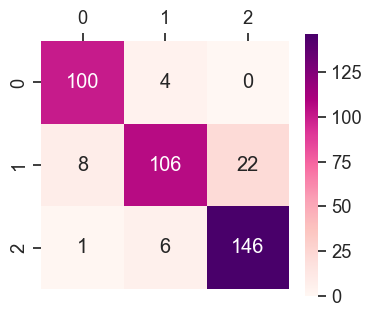

In [ ]:
res = get_confusion_matrix(cm)

<strong>Models</strong>: Define models for comparison.

In [ ]:
# Naive Bayes
nb_classifier = BernoulliNB()
nb_model = REWClassifier(name='Naive Bayes', classifier=nb_classifier)

# Multi-Layer Perceptron
mlp_classifier = MLPClassifier(
    hidden_layer_sizes = (100, 100),
    activation='relu', 
                                    solver='lbfgs',
                                    random_state=42,
                                    max_iter=5000)
mlp_model = REWClassifier(name='Multi-Layer Perceptron', classifier=mlp_classifier)

# Deep Neural Network
dnn_classifier = MLPClassifier(hidden_layer_sizes = (100, 100, 100),
                                    activation='relu', 
                                    solver='lbfgs',
                                    random_state=42,
                                    max_iter=5000)
dnn_model = REWClassifier(name='Deep Neural Network', classifier=dnn_classifier)


# K-Nearest Neighbor
knn_classifier = KNeighborsClassifier(n_neighbors=10,
                                    metric='l1')
knn_model = REWClassifier(name='K-Nearest Neighbor', classifier=knn_classifier)
        

# Decision Tree
dt_classifier = DecisionTreeClassifier(criterion='gini',
                                    max_depth=6)
dt_model = REWClassifier(name='Decision Tree', classifier=dt_classifier)


# Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100,
                                    criterion='gini',
                                    bootstrap=True,
                                    max_depth=6)
rf_model = REWClassifier(name='Random Forest', classifier=rf_classifier)


# Support Vector Machine
svc_classifier = SVC(probability=True)
svc_model = REWClassifier(name='Support Vector Machine', classifier=svc_classifier)


# Logistic Regression
lr_classifier = LogisticRegression(l1_ratio=0)
lr_model = REWClassifier(name='Logistic Regression', classifier=lr_classifier)


models = [nb_model, mlp_model, dnn_model, knn_model, dt_model, rf_model, svc_model, lr_model]

In [ ]:
acc, f1, auc, cm = kfoldcv(nb_model, X_, y_categorical)

TypeError: unsupported format string passed to NoneType.__format__

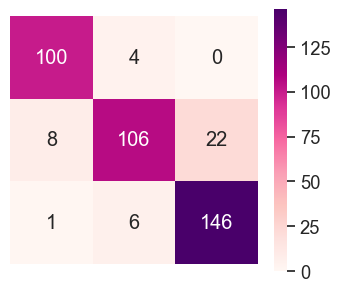

In [ ]:
res = get_confusion_matrix(cm)

In [ ]:
res

<Axes: xlabel='Naive Bayes'>

In [ ]:
accuracies = {}
f1_scores = {}
auc_rocs = {}
confusion_matrices = []
for model in models:
    print(f'Evaluating {model.name} model...')
    results = None

    results = kfoldcv(model, X_, y_categorical)

    accuracies[model.name] = results[0]
    f1_scores[model.name] = results[1]
    auc_rocs[model.name] = results[2]
    # confusion_matrices.append(results[3])
    # get_confusion_matrix(confusion_matrix=results[3], 
    #                      model_name=model.name,
    #                             class_labels=class_labels, 
    #                             save_to=f'{model.name}_cm.png')
    
    import json
    # write numerical metrics to a file
    with open('model_accuracies.json', 'w') as f:
        json.dump(accuracies, f)
    with open('model_f1_scores.json', 'w') as f:
        json.dump(f1_scores, f)
    with open('model_aucs.json', 'w') as f:
        json.dump(auc_rocs, f)

Evaluating Naive Bayes model...
Evaluating Multi-Layer Perceptron model...
Evaluating Deep Neural Network model...
Evaluating K-Nearest Neighbor model...


c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Evaluating Decision Tree model...
Evaluating Random Forest model...
Evaluating Support Vector Machine model...
Evaluating Logistic Regression model...
